In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import pandas as pd
import h5py
from scipy.signal import savgol_filter
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from pathlib import Path
import sys
sys.path.append('../../')

from codebase.burst_glide_analysis import find_complete_burst_glide_cycles, compute_pairwise_response_features

# Compute burst features for each age group for clustering 

In [17]:
exp_details = pd.read_csv('../../Data/groups_by_age/exp_details.csv')
data_path = '../../Data/groups_by_age/h5_files_cleaned/'
fish_ages = [4,6,8] 
nfish = 4
fps = 121 # Hz

# params for smoothing v and detecting burst/glide cycles
#for savgol_filter
window_length = 21 #frames
polyorder = 2
# for identifying burst and glide points
min_burst_duration = 0.01 * fps #frames
min_glide_duration = 0.01 * fps #frames
prominence_threshold = 10 # for peak detection

# features
private_features = ["T_burst","distance_to_wall","cum_delta_theta", "delta_v"]
neighbor_wise_features = ["initial_L","delta_L","reaction_time","initial_m","delta_m","cosine_avoidance"]
feature_names = private_features + [f"{feature}_{i}" for feature in neighbor_wise_features for i in range(nfish-1)]


In [19]:
feature_dfs_path = Path('agewise_burst_features_dfs.pkl')
if feature_dfs_path.is_file():
    with open(feature_dfs_path, 'rb') as f:
        agewise_burst_features_dfs = pickle.load(f)
else:
    agewise_burst_features_dfs = {f'{age}wpf': [] for age in fish_ages}
    for ii,age in enumerate(fish_ages):
        # features pooled over all fish and all experiments 
        pooled_features = {feature : [] for feature in feature_names}
        exp_list = np.flatnonzero(exp_details["fish_age"]==age)

        for i in exp_list:
            fpath = f'{data_path}{exp_details["experiment"][i]}.h5'
            f = h5py.File(fpath,'r')
            arena_radius = exp_details["px_to_mm"][i] * 500 # mm

            x = f['tracks'][:nfish,0,:,:]
            y = f['tracks'][:nfish,1,:,:]
            nose_x = (x[:,0,:] + x[:,1,:])/2 # avg L and R eye positions to get nose position
            nose_y = (y[:,0,:] + y[:,1,:])/2

            # compute vx,vy after smoothing using savgol_filter. it implies dt=1
            vx = savgol_filter(nose_x, window_length=window_length, polyorder=polyorder,deriv=1,delta=1/fps) #array of shape (fish  x frames)
            vy = savgol_filter(nose_y, window_length=window_length, polyorder=polyorder,deriv=1,delta=1/fps)
            v_smooth = np.sqrt(vx**2 + vy**2)

            # head angles using nose and mid-bladder (without smoothing)
            head_angles = np.arctan2(nose_y - y[:,3,:],nose_x - x[:,3,:])

            burst_glide_cycles_all_fish = []
            # find burst and glide cycles for each fish 
            for fi in range(nfish):
                bg_cycles = find_complete_burst_glide_cycles(v_smooth[fi,:], min_burst_duration, min_glide_duration, prominence_threshold)
                burst_glide_cycles_all_fish.append(bg_cycles)

            # next, calculate burst features for each fish
            for fi in range(nfish):
                neighbor_idxs = np.setdiff1d(np.arange(nfish),fi)
                features = compute_pairwise_response_features(fi, neighbor_idxs, burst_glide_cycles_all_fish, head_angles, nose_x, nose_y, v_smooth, arena_radius, fps)
                for feature in pooled_features.keys():
                    pooled_features[feature].append(features[feature])
                            
        # concatenate features all experiments of this age
        for feature in pooled_features.keys():
            pooled_features[feature] = np.concatenate(pooled_features[feature])

        # save
        agewise_burst_features_dfs[f'{age}wpf'] = pd.DataFrame(pooled_features).dropna(ignore_index=True)

    # write to file
    with open(feature_dfs_path,'wb') as f:
        pickle.dump(agewise_burst_features_dfs,f)

# Distributions of features for all ages

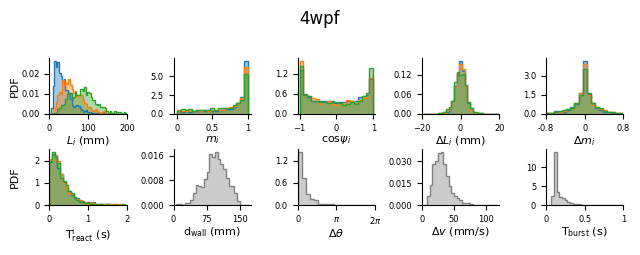

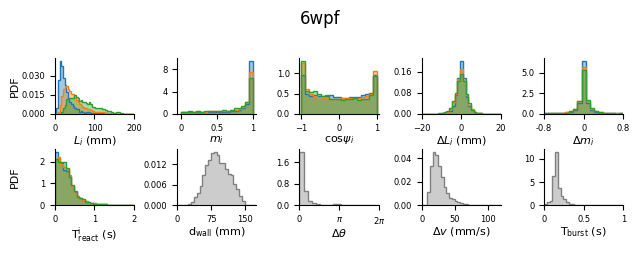

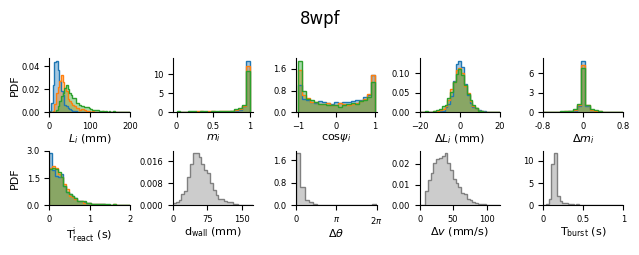

In [21]:
# visualize feature distributions across ages
w = 6.5
h = 2.5
axlabel_size = 8
title_size = 12
tick_size = 6
legend_size = 6

# three distinct colors for three neighbors
colors_n = ['#1f77b4', '#ff7f0e', '#2ca02c'] # blue, orange, green

neighbor_wise_features_and_colors ={
    "initial_L":colors_n, "initial_m":colors_n, "cosine_avoidance":colors_n, "delta_L":colors_n, "delta_m":colors_n, "reaction_time":colors_n
} 
single_features_and_colors = {
    "distance_to_wall":'grey', "cum_delta_theta":'grey', "delta_v":'grey', "T_burst":'grey'}

bins = {
    "initial_L" : np.linspace(0,200,50),
    "initial_m" : np.linspace(0,1,20),
    "cosine_avoidance" : np.linspace(-1,1,20),
    "distance_to_wall" : np.linspace(0,180,30),
    "cum_delta_theta" : np.linspace(0,2*np.pi,20),
    "delta_L" : np.linspace(-20,20,30),
    "delta_m" : np.linspace(-0.8,0.8,20),
    "reaction_time" : np.linspace(0,2,30),
    "T_burst" : np.linspace(0,1,30),
    "delta_v" : np.linspace(0,120,30),
}

xlabels = {
    "initial_L" : "$L_i$ (mm)",
    "initial_m" : "$m_i$",
    "cosine_avoidance" : r"$\mathrm{cos}\psi_i$",
    "distance_to_wall" : r"$\mathrm{d_{wall}}$ (mm)",
    "cum_delta_theta" : r"$\Delta\theta$",
    "delta_L" : r"$\Delta L_i$ (mm)",
    "delta_m" : r"$\Delta m_i$",
    "reaction_time" : r"$\mathrm{T^i_{react}}$ (s)",
    "delta_v" : r"$\Delta v$ (mm/s)",
    "T_burst" : r"$\mathrm{T_{burst}}$ (s)",
}

xlim = {
    "initial_L" : [0,200],
    "initial_m" : [-0.05,1.05],
    "cosine_avoidance" : [-1.05,1.05],
    "distance_to_wall" : [0,175],
    "cum_delta_theta" : [0,2*np.pi],
    "delta_L" : [-20,20],
    "delta_m" : [-0.8,0.8],
    "reaction_time" : [0,2],
    "delta_v" : [0,120],
    "T_burst" : [0,1],
}
xticks ={
    "initial_L" : {'ticks':[0,100,200]},
    "initial_m" : {'ticks':[0,0.5,1], 'labels':['0','0.5','1']},
    "cosine_avoidance" : {'ticks':[-1,0,1]},
    "distance_to_wall" : {'ticks':[0,75,150]},
    "cum_delta_theta" : {'ticks':[0,np.pi,2*np.pi], 'labels':['0',r'$\pi$',r'$2\pi$']},
    "delta_L" : {'ticks':[-20,0,20]},
    "delta_m" : {'ticks':[-0.8,0,0.8], 'labels':['-0.8','0','0.8']},
    "reaction_time" : {'ticks':[0,1,2]},
    "delta_v" : {'ticks':[0,50,100]},
    "T_burst" : {'ticks':[0,0.5,1], 'labels':['0','0.5','1']},

}

for j in range(3):
    age = fish_ages[j]
    featureDF = agewise_burst_features_dfs[f'{age}wpf']
    ncols = 5
    n_plots = len(neighbor_wise_features_and_colors) + len(single_features_and_colors)
    nrows = int(np.ceil(n_plots/ncols))
    fig, ax = plt.subplots(nrows,ncols,figsize=(w,h))
    ax = ax.flatten()
    ind = 0
    for feature_name,colors in neighbor_wise_features_and_colors.items():
        for i in range(3):
            hist = ax[ind].hist(featureDF[f"{feature_name}_{i}"],bins=bins[feature_name],density=True, color=colors[i], edgecolor='none', histtype="stepfilled", label=f"Neighbor {i+1}", alpha=0.4)
            # step histogram
            ax[ind].hist(featureDF[f"{feature_name}_{i}"], bins=bins[feature_name], density=True, histtype='step', color=colors[i], linewidth=1)
        if ind % ncols == 0:
            ax[ind].set_ylabel("PDF", fontsize=axlabel_size,labelpad=1)
        ax[ind].set_xlabel(xlabels[feature_name], fontsize=axlabel_size,labelpad=1)
        # turn off top and right spines
        ax[ind].spines['top'].set_visible(False)
        ax[ind].spines['right'].set_visible(False)
        ax[ind].set_xticks(**xticks[feature_name])
        ax[ind].yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax[ind].tick_params(axis='both', which='major', labelsize=tick_size)
        ax[ind].set_xlim(xlim[feature_name])
        # if ind == 0:
        #     ax[ind].legend(fontsize=legend_size, frameon=False, loc='lower left', bbox_to_anchor=(0,0.8), handlelength=1)
        ind += 1

    for feature_name,color in single_features_and_colors.items():
        ax[ind].hist(featureDF[feature_name],bins=bins[feature_name],density=True, color=color, edgecolor='none', histtype="stepfilled", alpha=0.4)
        ax[ind].hist(featureDF[feature_name],bins=bins[feature_name],density=True, color=color, histtype="step", alpha=1, linewidth=1)
        if ind % ncols == 0:
            ax[ind].set_ylabel("PDF", fontsize=axlabel_size,labelpad=1)
        ax[ind].set_xlabel(xlabels[feature_name], fontsize=axlabel_size, labelpad=1)
        # turn off top and right spines
        ax[ind].spines['top'].set_visible(False)
        ax[ind].spines['right'].set_visible(False)
        ax[ind].set_xticks(**xticks[feature_name])
        ax[ind].yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax[ind].tick_params(axis='both', which='major', labelsize=tick_size)
        ax[ind].set_xlim(xlim[feature_name])
        ind += 1
    # remove empty subplots
    for i in range(n_plots, len(ax)):
        fig.delaxes(ax[i])
    

    fig.align_ylabels()
    fig.suptitle(f"{age}wpf", fontsize=title_size, y=1)
    fig.tight_layout(h_pad=0.1,w_pad=0.5)
